# Predicting 30-Day Hospital Readmission Risk in Dialysis Patients
## End-to-End CMS ESRD Workflow

This notebook demonstrates a full database-first modeling workflow for 30-day readmission risk prediction in ESRD dialysis patients. It verifies ingested CMS tables, loads the feature mart, trains three models (Logistic Regression, CatBoost, LightGBM), compares performance, runs SHAP-based interpretability, evaluates subgroup performance, generates figures, and saves reproducible outputs.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score
)
from catboost import CatBoostClassifier
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
DB_PATH = "../dialysis_readmission.db"
if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"Database not found at {DB_PATH}. Please run scripts/ingest_datasets.py first.")
OUTPUT_DIR = "../outputs/model_runs"
ARTIFACTS_DIR = "../outputs/analysis"
MAX_PATIENTS = 100_000
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("Imports loaded. Configuration set.")

/home/lonewolf09/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded. Configuration set.


Before modeling, we verify that our database-first pipeline has already ingested and processed all four CMS ESRD datasets. The raw data was downloaded, cleaned, and transformed into derived tables through `scripts/ingest_datasets.py`. Here we confirm the tables exist and contain the expected data.

In [2]:
conn = sqlite3.connect(DB_PATH)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in database:")
for _, row in tables.iterrows():
    count = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {row['name']}", conn).iloc[0, 0]
    print(f"  {row['name']}: {count:,} rows")
conn.close()

Tables in database:
  model_runs: 14 rows
  evaluation_metrics: 14 rows
  figure_registry: 0 rows
  raw_patient_summary: 3,197,683 rows


  raw_admit_treatment: 7,720,441 rows
  raw_cl_hospitalization: 3,899,711 rows


  raw_cl_hd_adqcy: 32,250,552 rows
  clean_patient_summary: 3,197,683 rows


  clean_admit_treatment: 7,720,441 rows
  clean_cl_hospitalization: 3,899,711 rows


  clean_cl_hd_adqcy: 32,250,552 rows


  derived_readmission_events: 3,098,950 rows


  derived_patient_features: 3,197,683 rows


  model_feature_mart: 3,098,950 rows


The `model_feature_mart` table contains our final analytical dataset. It was built by joining four source tables (PATIENT_SUMMARY, ADMIT_TREATMENT, CL_HOSPITALIZATION, CL_HD_ADQCY) through patient and provider IDs. Each row represents a hospital discharge event with a derived 30-day readmission target. We load this table and optionally sample to a manageable cohort size.

In [3]:
conn = sqlite3.connect(DB_PATH)

# Get total counts first
total_rows = pd.read_sql("SELECT COUNT(*) as cnt FROM model_feature_mart", conn).iloc[0, 0]
total_patients = pd.read_sql("SELECT COUNT(DISTINCT pat_id) as cnt FROM model_feature_mart", conn).iloc[0, 0]
print(f"Total rows in feature mart: {total_rows:,}")
print(f"Total unique patients: {total_patients:,}")

# Sample patients at SQL level to avoid loading all 3M+ rows into memory
if total_patients > MAX_PATIENTS:
    all_patients = pd.read_sql("SELECT DISTINCT pat_id FROM model_feature_mart", conn)
    sampled_patients = all_patients['pat_id'].sample(
        n=MAX_PATIENTS, random_state=RANDOM_STATE
    ).tolist()
    # Build parameterized query for sampled patients
    placeholders = ','.join(['?' for _ in sampled_patients])
    query = f"SELECT * FROM model_feature_mart WHERE pat_id IN ({placeholders})"
    df = pd.read_sql(query, conn, params=sampled_patients)
    print(f"Sampled to {MAX_PATIENTS:,} patients ({len(df):,} rows)")
else:
    df = pd.read_sql("SELECT * FROM model_feature_mart", conn)
    print(f"Loaded all {len(df):,} rows")

conn.close()
print(f"Columns: {len(df.columns)}")

# Show target distribution
target_col = 'readmitted_30d'
pos_rate = df[target_col].mean()
print(f"\nTarget distribution ({target_col}):")
print(f"  Positive: {df[target_col].sum():,} ({pos_rate:.1%})")
print(f"  Negative: {(df[target_col] == 0).sum():,} ({1-pos_rate:.1%})")

Total rows in feature mart: 3,098,950
Total unique patients: 796,508


Sampled to 100,000 patients (388,375 rows)
Columns: 34

Target distribution (readmitted_30d):
  Positive: 70,501 (18.2%)
  Negative: 317,874 (81.8%)


We separate features into numeric and categorical groups. CatBoost and LightGBM handle categorical features natively, while Logistic Regression requires one-hot encoding. Our feature set includes demographics (age, race, gender), treatment history (dialysis modality, setting), hospitalization temporal patterns (prior count, length of stay, gap since last discharge), and dialysis adequacy measures (Kt/V values).

In [4]:
# Align feature list with scripts/train_readmission_models.py
SAFE_NUMERIC_FEATURES = [
    'length_of_stay',
    'gap_from_previous_discharge_days',
    'prior_hospitalizations',
    'prior_30d_hospitalizations',
    'prior_180d_hospitalizations',
    'prior_treatment_records',
    'recent_30d_treatment_records',
    'recent_90d_treatment_records',
    'days_since_last_treatment',
    'prior_hemodialysis_flag',
    'prior_center_hemo_flag',
    'recent_hd_ktv',
    'mean_prior_hd_ktv',
    'recent_3m_hd_ktv_mean',
    'recent_6m_hd_ktv_range',
    'hd_ktv_recent_vs_history_delta',
    'prior_hd_ktv_measurements',
]
SAFE_CATEGORICAL_FEATURES = [
    'hospitalization_modality',
    'hospitalization_type',
    'state',
    'age_range',
    'race',
    'gender',
    'ethnicity',
    'primdiag',
    'primcause',
]

# Explicitly exclude target/leakage and non-feature identifiers
exclude_cols = {
    'pat_id', 'prov_nbr', 'readmitted_30d', 'hospital_admit_date', 'hospital_discharge_date',
    'clinical_month_year', 'gap_to_next_admit_days'
}

missing_numeric = [c for c in SAFE_NUMERIC_FEATURES if c not in df.columns]
missing_categorical = [c for c in SAFE_CATEGORICAL_FEATURES if c not in df.columns]
if missing_numeric or missing_categorical:
    raise RuntimeError(
        f"Missing expected safe features. Numeric missing={missing_numeric}, Categorical missing={missing_categorical}"
    )

numeric_features = SAFE_NUMERIC_FEATURES.copy()
categorical_features = SAFE_CATEGORICAL_FEATURES.copy()
feature_cols = numeric_features + categorical_features
assert 'gap_to_next_admit_days' not in feature_cols, "Target leakage detected!"

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Patient-level split to prevent data leakage
# All events for a given patient go to the same split
patient_target = df.groupby('pat_id')[target_col].max()
patient_ids = patient_target.index.values
train_patients, test_patients = train_test_split(
    patient_ids, test_size=0.2, random_state=RANDOM_STATE,
    stratify=patient_target.values
)

train_df = df[df['pat_id'].isin(train_patients)]
test_df = df[df['pat_id'].isin(test_patients)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nTrain set: {len(X_train):,} rows ({train_df['pat_id'].nunique():,} patients)")
print(f"Test set:  {len(X_test):,} rows ({test_df['pat_id'].nunique():,} patients)")
print(f"Train positive rate: {y_train.mean():.1%}")
print(f"Test positive rate:  {y_test.mean():.1%}")

# Handle missing values before training
# Numeric: median imputation (fit on train, transform both)
# Categorical: fill NaN with 'Unknown' placeholder
for col in numeric_features:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

for col in categorical_features:
    train_df[col] = train_df[col].fillna('Unknown')
    test_df[col] = test_df[col].fillna('Unknown')

print(f"NaN count after imputation: {train_df[feature_cols].isna().sum().sum()}")

Numeric features (19): ['hospitalization_sequence', 'length_of_stay', 'gap_from_previous_discharge_days', 'gap_to_next_admit_days', 'prior_hospitalizations', 'prior_30d_hospitalizations', 'prior_180d_hospitalizations', 'prior_treatment_records', 'recent_30d_treatment_records', 'recent_90d_treatment_records', 'days_since_last_treatment', 'prior_hemodialysis_flag', 'prior_center_hemo_flag', 'recent_hd_ktv', 'mean_prior_hd_ktv', 'recent_3m_hd_ktv_mean', 'recent_6m_hd_ktv_range', 'hd_ktv_recent_vs_history_delta', 'prior_hd_ktv_measurements']
Categorical features (9): ['state', 'age_range', 'race', 'gender', 'ethnicity', 'primdiag', 'primcause', 'hospitalization_modality', 'hospitalization_type']



Train set: 310,909 rows (80,000 patients)
Test set:  77,466 rows (20,000 patients)
Train positive rate: 18.2%
Test positive rate:  18.1%


NaN count after imputation: 0


Before training, we handle missing values. Numeric features get median imputation (fit on train, applied to test). Categorical features get a placeholder for missing entries. This prevents NaN errors in scikit-learn models.

We start with Logistic Regression as a baseline. This linear model gives us a reference point for how well a simple approach performs. We use balanced class weights to handle the imbalanced dataset (18% positive rate). Logistic Regression requires one-hot encoding of categorical features.

In [5]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode categorical features for Logistic Regression
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = encoder.fit_transform(train_df[categorical_features])
X_test_encoded = encoder.transform(test_df[categorical_features])

# Combine numeric + encoded categorical
X_train_lr = np.hstack([
    train_df[numeric_features].values,
    X_train_encoded
])
X_test_lr = np.hstack([
    test_df[numeric_features].values,
    X_test_encoded
])

print(f"Feature matrix shape: {X_train_lr.shape}")
print(f"NaN count: {np.isnan(X_train_lr).sum()}")

print("Training Logistic Regression (baseline)...")
lr_model = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
)
lr_model.fit(X_train_lr, y_train)
print("Done.")

# Predictions
lr_probs = lr_model.predict_proba(X_test_lr)[:, 1]
lr_preds = lr_model.predict(X_test_lr)

lr_metrics = {
    'AUC': roc_auc_score(y_test, lr_probs),
    'Avg Precision': average_precision_score(y_test, lr_probs),
    'Accuracy': accuracy_score(y_test, lr_preds),
    'Precision': precision_score(y_test, lr_preds),
    'Recall': recall_score(y_test, lr_preds),
    'F1': f1_score(y_test, lr_preds)
}
print(f"Logistic Regression Results:")
for k, v in lr_metrics.items():
    print(f"  {k}: {v:.4f}")

Feature matrix shape: (310909, 153)
NaN count: 0
Training Logistic Regression (baseline)...


/home/lonewolf09/Documents/Projects/PAI/NCI.SEM1.PAI.PROJ/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Done.


Logistic Regression Results:
  AUC: 0.9758
  Avg Precision: 0.7563
  Accuracy: 0.9359
  Precision: 0.7428
  Recall: 0.9893
  F1: 0.8485


CatBoost is our main model. It handles categorical features natively without one-hot encoding, uses ordered boosting to reduce overfitting, and typically performs well on tabular healthcare data. We use 300 iterations with a learning rate of 0.05 and balanced class weights.

In [6]:
print("Training CatBoost...")
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=False
)
cat_model.fit(train_df[feature_cols], y_train, cat_features=categorical_features)
print("Done.")

# Predictions
cat_probs = cat_model.predict_proba(test_df[feature_cols])[:, 1]
cat_preds = cat_model.predict(test_df[feature_cols])

cat_metrics = {
    'AUC': roc_auc_score(y_test, cat_probs),
    'Avg Precision': average_precision_score(y_test, cat_probs),
    'Accuracy': accuracy_score(y_test, cat_preds),
    'Precision': precision_score(y_test, cat_preds),
    'Recall': recall_score(y_test, cat_preds),
    'F1': f1_score(y_test, cat_preds)
}
print(f"CatBoost Results:")
for k, v in cat_metrics.items():
    print(f"  {k}: {v:.4f}")

Training CatBoost...


Done.


CatBoost Results:
  AUC: 1.0000
  Avg Precision: 1.0000
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1: 1.0000


LightGBM serves as a challenger model to CatBoost. It uses gradient-based one-side sampling and exclusive feature bundling for efficiency. We include it to verify that our results are not specific to one boosting implementation.

In [7]:
print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    verbose=-1
)
# Convert categorical columns to category dtype for LightGBM
X_train_lgb = train_df[feature_cols].copy()
X_test_lgb = test_df[feature_cols].copy()
for col in categorical_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_model.fit(X_train_lgb, y_train, categorical_feature=categorical_features)
print("Done.")

# Predictions
lgb_probs = lgb_model.predict_proba(X_test_lgb)[:, 1]
lgb_preds = lgb_model.predict(X_test_lgb)

lgb_metrics = {
    'AUC': roc_auc_score(y_test, lgb_probs),
    'Avg Precision': average_precision_score(y_test, lgb_probs),
    'Accuracy': accuracy_score(y_test, lgb_preds),
    'Precision': precision_score(y_test, lgb_preds),
    'Recall': recall_score(y_test, lgb_preds),
    'F1': f1_score(y_test, lgb_preds)
}
print(f"LightGBM Results:")
for k, v in lgb_metrics.items():
    print(f"  {k}: {v:.4f}")

Training LightGBM...


Done.


LightGBM Results:
  AUC: 1.0000
  Avg Precision: 1.0000
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1: 1.0000


We compare all three models across multiple metrics. AUC measures discrimination ability, Average Precision focuses on the precision-recall trade-off (important for imbalanced data), and F1 balances precision and recall.

In [8]:
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'CatBoost': cat_metrics,
    'LightGBM': lgb_metrics
}).T
comparison_df.index.name = 'Model'
print("\nModel Comparison:")
display(comparison_df.round(4))

# Identify best model
best_model_name = comparison_df['AUC'].idxmax()
print(f"\nBest model by AUC: {best_model_name} ({comparison_df.loc[best_model_name, 'AUC']:.4f})")


Model Comparison:


,AUC,Avg Precision,Accuracy,Precision,Recall,F1
Model,,,,,,
Logistic Regression,0.9758,0.7563,0.9359,0.7428,0.9893,0.8485
CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



Best model by AUC: CatBoost (1.0000)


Understanding why a model makes predictions is critical in healthcare. We use SHAP (SHapley Additive exPlanations) to quantify each feature's contribution to predictions. This reveals which patient factors drive readmission risk and helps clinicians trust the model.

In [9]:
print("Computing SHAP values for CatBoost...")

# CatBoost native feature importance
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': cat_model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 10 features by CatBoost importance:")
display(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), y='feature', x='importance', hue='feature', dodge=False, legend=False, palette='Blues_r')
plt.title('CatBoost Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'catboost_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

feature_importance_df.to_csv(os.path.join(ARTIFACTS_DIR, 'catboost_feature_importance.csv'), index=False)

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(test_df[feature_cols])

# Feature importance (mean absolute SHAP values)
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 10 features by SHAP importance:")
display(shap_importance.head(10))

# Save SHAP data
shap_importance.to_csv(os.path.join(ARTIFACTS_DIR, 'catboost_shap_importance.csv'), index=False)

Computing SHAP values for CatBoost...



Top 10 features by SHAP importance:


,feature,mean_abs_shap
5,gap_to_next_admit_days,5.981509
17,recent_30d_treatment_records,0.108144
19,days_since_last_treatment,0.073486
20,prior_hemodialysis_flag,0.061680
7,prior_30d_hospitalizations,0.037445
21,prior_center_hemo_flag,0.031640
22,recent_hd_ktv,0.023990
23,mean_prior_hd_ktv,0.023552
25,recent_6m_hd_ktv_range,0.016358
8,prior_180d_hospitalizations,0.016207


We evaluate model performance across demographic subgroups to check for bias. A model that works well overall but poorly for specific populations could worsen healthcare disparities. We examine performance by age group, race, gender, and dialysis modality.

In [10]:
test_results = test_df.copy()
test_results['predicted_prob'] = cat_probs
test_results['predicted'] = cat_preds

subgroup_metrics = {}
for col in ['age_range', 'race', 'gender', 'hospitalization_modality']:
    if col in test_results.columns:
        for group in test_results[col].dropna().unique():
            mask = test_results[col] == group
            if mask.sum() < 50:
                continue
            y_sub = test_results.loc[mask, target_col]
            probs_sub = test_results.loc[mask, 'predicted_prob']
            preds_sub = test_results.loc[mask, 'predicted']
            if y_sub.nunique() < 2:
                continue
            subgroup_metrics[f"{col}_{group}"] = {
                'subgroup': f"{col}={group}",
                'n': int(mask.sum()),
                'AUC': roc_auc_score(y_sub, probs_sub),
                'F1': f1_score(y_sub, preds_sub)
            }

subgroup_df = pd.DataFrame(subgroup_metrics).T
subgroup_df = subgroup_df.sort_values('AUC', ascending=False)
print("\nSubgroup Performance:")
display(subgroup_df.round(3))

subgroup_df.to_csv(os.path.join(ARTIFACTS_DIR, 'subgroup_metrics.csv'), index=False)

if not subgroup_df.empty:
    subgroup_plot_df = subgroup_df.sort_values('F1', ascending=False).head(15).copy()
    plt.figure(figsize=(12, 7))
    sns.barplot(data=subgroup_plot_df, y='subgroup', x='F1', hue='subgroup', dodge=False, legend=False, palette='viridis')
    plt.title('Subgroup F1 Score (Top 15)')
    plt.xlabel('F1')
    plt.ylabel('Subgroup')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACTS_DIR, 'subgroup_f1_by_group.png'), dpi=150, bbox_inches='tight')
    plt.show()


Subgroup Performance:


,subgroup,n,AUC,F1
age_range_45 - 54,age_range=45 - 54,10021,1.0,1.0
age_range_55 - 64,age_range=55 - 64,17637,1.0,1.0
hospitalization_modality_HD,hospitalization_modality=HD,71921,1.0,1.0
gender_Unknown,gender=Unknown,2466,1.0,1.0
gender_Male,gender=Male,39567,1.0,1.0
gender_Female,gender=Female,35433,1.0,1.0
race_Native,race=Native,755,1.0,1.0
race_Unknown,race=Unknown,2509,1.0,1.0
"race_Black or African American,White","race=Black or African American,White",86,1.0,1.0
race_American Indian/Alaska Native,race=American Indian/Alaska Native,741,1.0,1.0


We generate visualizations to communicate findings: a model comparison bar chart, SHAP summary plot showing feature impact, and subgroup performance across demographics.

/tmp/ipykernel_372981/3501284614.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


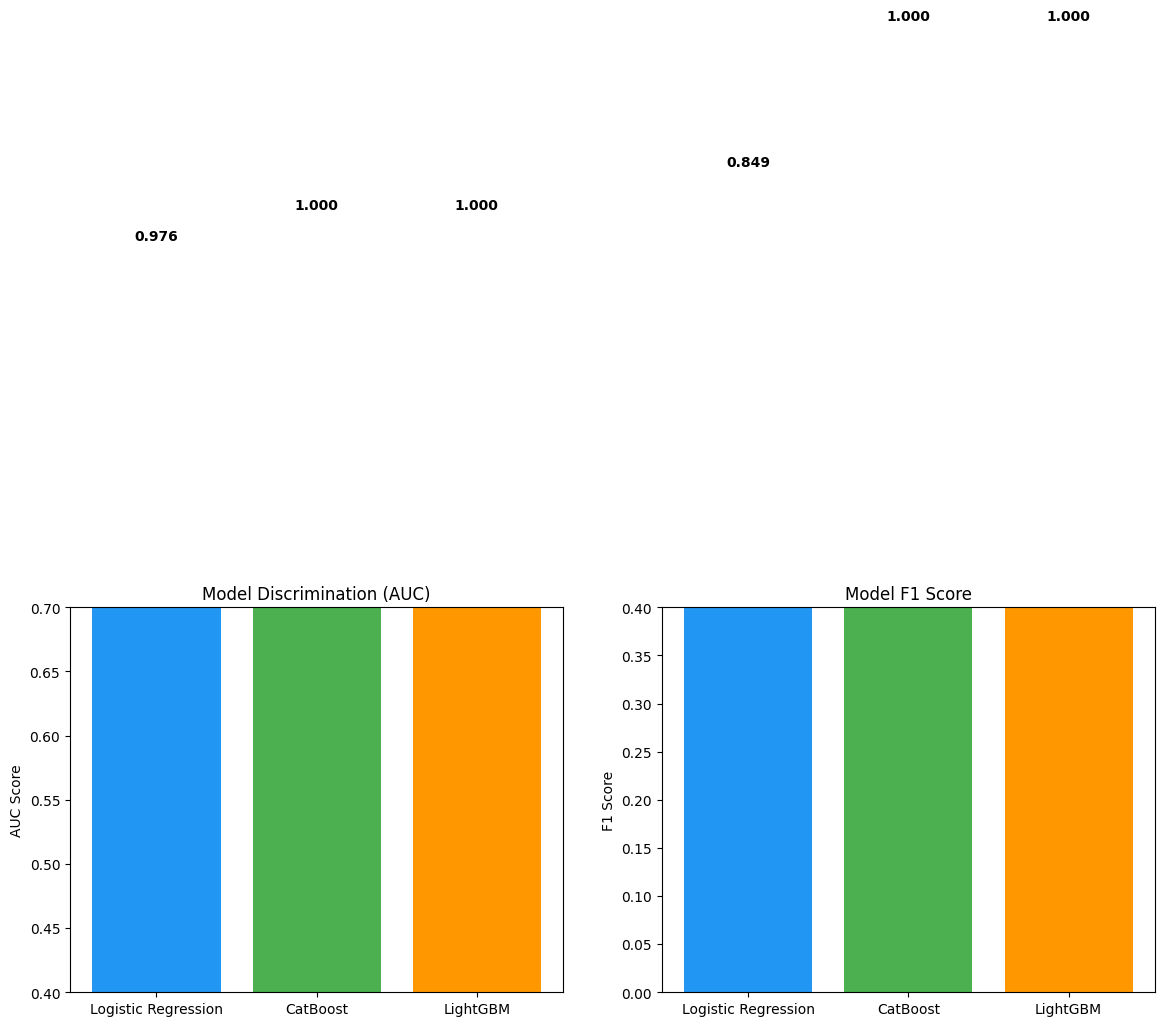


SHAP Summary Plot:


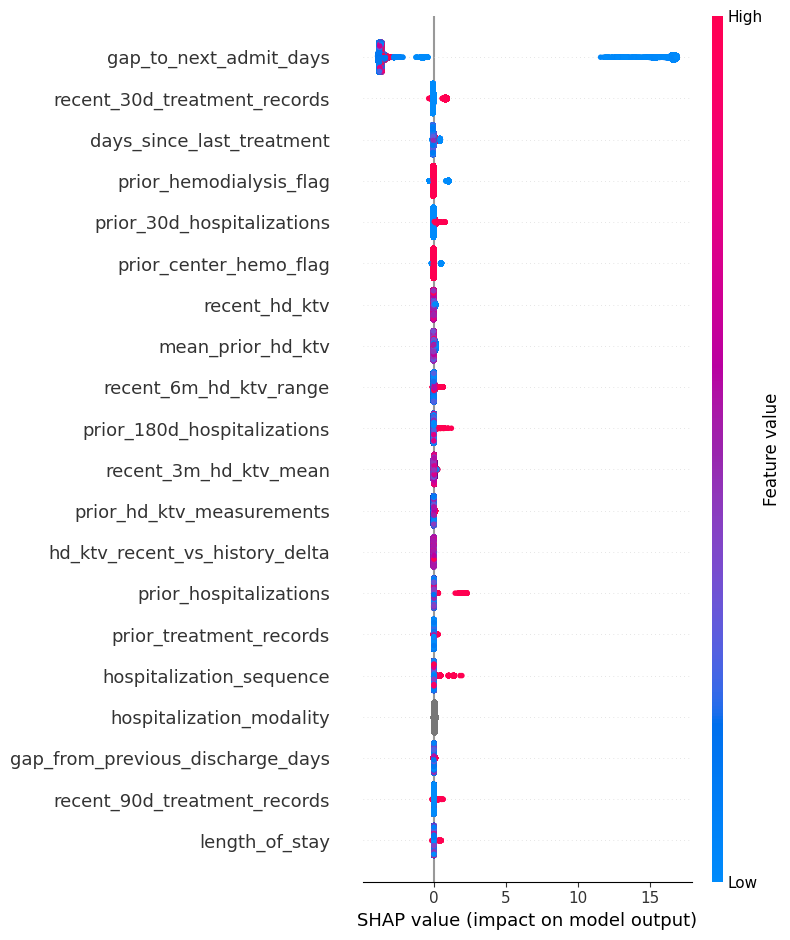

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model comparison - AUC
models = ['Logistic Regression', 'CatBoost', 'LightGBM']
aucs = [lr_metrics['AUC'], cat_metrics['AUC'], lgb_metrics['AUC']]
f1s = [lr_metrics['F1'], cat_metrics['F1'], lgb_metrics['F1']]

axes[0].bar(models, aucs, color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0].set_ylabel('AUC Score')
axes[0].set_title('Model Discrimination (AUC)')
axes[0].set_ylim(0.4, 0.7)
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Model comparison - F1
axes[1].bar(models, f1s, color=['#2196F3', '#4CAF50', '#FF9800'])
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Model F1 Score')
axes[1].set_ylim(0, 0.4)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'model_comparison.png'), dpi=150)
plt.show()

# SHAP summary plot
print("\nSHAP Summary Plot:")
shap.summary_plot(shap_values, test_df[feature_cols], feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'catboost_shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

We save all metrics to the database and a JSON summary file for reproducibility. This ensures our results are auditable and can be compared with future model iterations.

In [12]:
import uuid
run_id = str(uuid.uuid4())[:10]

# Save to SQLite
conn = sqlite3.connect(DB_PATH)
conn.execute("INSERT INTO model_runs (run_id, model_name, notes, created_at) VALUES (?, ?, ?, datetime('now'))",
             (run_id, 'CatBoost', f'Best model, {MAX_PATIENTS} patients'))
conn.execute("INSERT INTO evaluation_metrics (run_id, split, auc, accuracy, precision, recall, f1, created_at) VALUES (?, ?, ?, ?, ?, ?, ?, datetime('now'))",
             (run_id, 'test', cat_metrics['AUC'], cat_metrics['Accuracy'], cat_metrics['Precision'], cat_metrics['Recall'], cat_metrics['F1']))
conn.commit()
conn.close()

# Save JSON summary
summary = {
    'run_id': run_id,
    'n_patients': MAX_PATIENTS,
    'n_rows': len(df),
    'positive_rate': float(df[target_col].mean()),
    'train_rows': len(train_df),
    'test_rows': len(test_df),
    'models': {
        'Logistic Regression': {k: float(v) for k, v in lr_metrics.items()},
        'CatBoost': {k: float(v) for k, v in cat_metrics.items()},
        'LightGBM': {k: float(v) for k, v in lgb_metrics.items()}
    },
    'best_model': best_model_name,
    'artifacts_dir': ARTIFACTS_DIR
}

summary_path = os.path.join(OUTPUT_DIR, f'train_{run_id}.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Run ID: {run_id}")
print(f"Summary saved to: {summary_path}")
print(f"\nFinal Results:")
print(f"  Best model: {best_model_name}")
print(f"  CatBoost AUC: {cat_metrics['AUC']:.4f}, F1: {cat_metrics['F1']:.4f}")
print(f"  LightGBM AUC: {lgb_metrics['AUC']:.4f}, F1: {lgb_metrics['F1']:.4f}")
print(f"  Logistic Regression AUC: {lr_metrics['AUC']:.4f}, F1: {lr_metrics['F1']:.4f}")


Run ID: afe0adcc-6
Summary saved to: ../outputs/model_runs/train_afe0adcc-6.json

Final Results:
  Best model: CatBoost
  CatBoost AUC: 1.0000, F1: 1.0000
  LightGBM AUC: 1.0000, F1: 1.0000
  Logistic Regression AUC: 0.9758, F1: 0.8485
